In [1]:
from pathlib import Path
import random

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim

import numpy as np
from tqdm import tqdm

In [2]:
%reload_ext tensorboard
%tensorboard --logdir ../runs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/home/chris/miniconda3/envs/ramenv/bin/tensorboard", line 6, in <module>
    from tensorboard.main import run_main
  File "/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

In [3]:
rows, cols = 64, 64

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA no esta disponible. Este notebook requiere entrenamiento en GPU.")

device = torch.device("cuda")
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.benchmark = True
print(device)

DATA_DIR = Path("../data/dataset2-master/dataset2-master/images")
TENSORBOARD_LOG_DIR = Path("../runs/vgg11_half")
TENSORBOARD_LOG_DIR.mkdir(parents=True, exist_ok=True)

TENSORBOARD_BN_LOG_DIR = Path("../runs/vgg11_half_bn")
TENSORBOARD_BN_LOG_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

train_dir = DATA_DIR / "TRAIN"
test_dir = DATA_DIR / "TEST"

cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((rows, cols)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

num_classes = len(train_dataset.classes)
print(f"Clases detectadas ({num_classes}): {train_dataset.classes}")

Clases detectadas (4): ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [5]:
BATCH_SIZE = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [6]:
VGG11_HALF_CONFIG = [32, "M", 64, "M", 128, 128, "M", 256, 256, "M", 256, 256, "M"]


def make_vgg_layers(config, batch_norm: bool = False):
    layers = []
    in_channels = 3
    for layer in config:
        if layer == "M":
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            continue

        conv2d = nn.Conv2d(in_channels, layer, kernel_size=3, padding=1)
        if batch_norm:
            layers.extend([conv2d, nn.BatchNorm2d(layer), nn.ReLU(inplace=True)])
        else:
            layers.extend([conv2d, nn.ReLU(inplace=True)])
        in_channels = layer
    return nn.Sequential(*layers)


class VGG11Half(nn.Module):
    def __init__(self, num_classes: int = 10):
        super(VGG11Half, self).__init__()
        self.features = make_vgg_layers(VGG11_HALF_CONFIG, batch_norm=False)
        self.classifier = nn.Sequential(
            nn.Flatten(1, -1),
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [7]:
def train(model, device, train_loader, optimizer, criterion, epoch, writer=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Training epoch {epoch}")
    for batch_idx, (data, target) in progress_bar:
        data = data.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss * data.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        batch_acc = correct / total
        global_step = (epoch - 1) * len(train_loader) + batch_idx

        progress_bar.set_postfix(loss=batch_loss, acc=batch_acc)
        if writer is not None:
            writer.add_scalar("Loss/train_batch", batch_loss, global_step)
            writer.add_scalar("Accuracy/train_batch", batch_acc, global_step)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    if writer is not None:
        writer.add_scalar("Loss/train_epoch", epoch_loss, epoch)
        writer.add_scalar("Accuracy/train_epoch", epoch_acc, epoch)
    return epoch_loss, epoch_acc


def evaluate(model, device, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            outputs = model(data)
            loss = criterion(outputs, target)

            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [8]:
model_original = VGG11Half(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_original.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
writer = SummaryWriter(log_dir=str(TENSORBOARD_LOG_DIR))

sample_images, _ = next(iter(train_loader))
sample_images = sample_images.to(device, non_blocking=True)
with torch.no_grad():
    sample_outputs = model_original(sample_images)
print(f"Forward pass VGG11Half: {sample_outputs.shape}")

Forward pass VGG11Half: torch.Size([32, 4])


In [9]:
EPOCHS = 10

try:
    writer.add_graph(model_original, sample_images)
except Exception as exc:
    print(f"No se pudo registrar el grafo en TensorBoard: {exc}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model_original, device, train_loader, optimizer, criterion, epoch, writer)
    test_loss, test_acc = evaluate(model_original, device, test_loader, criterion)

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)
    tqdm.write(
        f"Epoch {epoch}/{EPOCHS} - "
        f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
        f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
    )

writer.close()
torch.save(model_original.state_dict(), MODELS_DIR / "vgg11_half.pth")

Training epoch 1: 100%|██████████| 312/312 [00:34<00:00,  8.92it/s, acc=0.248, loss=1.38]


Epoch 1/10 - train_loss: 1.3873 - train_acc: 0.2483 - test_loss: 1.3865 - test_acc: 0.2505


Training epoch 2: 100%|██████████| 312/312 [00:33<00:00,  9.29it/s, acc=0.251, loss=1.41]


Epoch 2/10 - train_loss: 1.3868 - train_acc: 0.2507 - test_loss: 1.3867 - test_acc: 0.2493


Training epoch 3: 100%|██████████| 312/312 [00:33<00:00,  9.24it/s, acc=0.253, loss=1.4] 


...

Epoch 8/10 - train_loss: 1.3872 - train_acc: 0.2465 - test_loss: 1.3869 - test_acc: 0.2509


Training epoch 9: 100%|██████████| 312/312 [00:33<00:00,  9.33it/s, acc=0.24, loss=1.37] 


Epoch 9/10 - train_loss: 1.3871 - train_acc: 0.2398 - test_loss: 1.3866 - test_acc: 0.2493


Training epoch 10: 100%|██████████| 312/312 [00:33<00:00,  9.31it/s, acc=0.251, loss=1.39]


Epoch 10/10 - train_loss: 1.3870 - train_acc: 0.2511 - test_loss: 1.3865 - test_acc: 0.2493


In [10]:
class VGG11HalfBN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super(VGG11HalfBN, self).__init__()
        self.features = make_vgg_layers(VGG11_HALF_CONFIG, batch_norm=True)
        self.classifier = nn.Sequential(
            nn.Flatten(1, -1),
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [11]:
model_bn = VGG11HalfBN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_bn.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
writer = SummaryWriter(log_dir=str(TENSORBOARD_BN_LOG_DIR))

sample_images, _ = next(iter(train_loader))
sample_images = sample_images.to(device, non_blocking=True)
with torch.no_grad():
    sample_outputs = model_bn(sample_images)
print(f"Forward pass VGG11HalfBN: {sample_outputs.shape}")

Forward pass VGG11HalfBN: torch.Size([32, 4])


In [12]:
EPOCHS = 10

try:
    writer.add_graph(model_bn, sample_images)
except Exception as exc:
    print(f"No se pudo registrar el grafo en TensorBoard: {exc}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model_bn, device, train_loader, optimizer, criterion, epoch, writer)
    test_loss, test_acc = evaluate(model_bn, device, test_loader, criterion)

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)
    tqdm.write(
        f"Epoch {epoch}/{EPOCHS} - "
        f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
        f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
    )

writer.close()
torch.save(model_bn.state_dict(), MODELS_DIR / "vgg11_half_bn.pth")

Training epoch 1: 100%|██████████| 312/312 [00:33<00:00,  9.20it/s, acc=0.371, loss=0.688]


Epoch 1/10 - train_loss: 1.2294 - train_acc: 0.3714 - test_loss: 1.5797 - test_acc: 0.2867


Training epoch 2: 100%|██████████| 312/312 [00:33<00:00,  9.24it/s, acc=0.651, loss=1.39] 


Epoch 2/10 - train_loss: 0.7186 - train_acc: 0.6506 - test_loss: 1.1595 - test_acc: 0.5022


Training epoch 3: 100%|██████████| 312/312 [00:33<00:00,  9.33it/s, acc=0.791, loss=0.256]


...

Epoch 8/10 - train_loss: 0.1225 - train_acc: 0.9577 - test_loss: 0.9905 - test_acc: 0.7873


Training epoch 9: 100%|██████████| 312/312 [00:34<00:00,  9.01it/s, acc=0.968, loss=0.0452] 


Epoch 9/10 - train_loss: 0.0882 - train_acc: 0.9679 - test_loss: 1.4315 - test_acc: 0.7748


Training epoch 10: 100%|██████████| 312/312 [00:33<00:00,  9.19it/s, acc=0.971, loss=0.46]   


Epoch 10/10 - train_loss: 0.0886 - train_acc: 0.9715 - test_loss: 2.3847 - test_acc: 0.5895


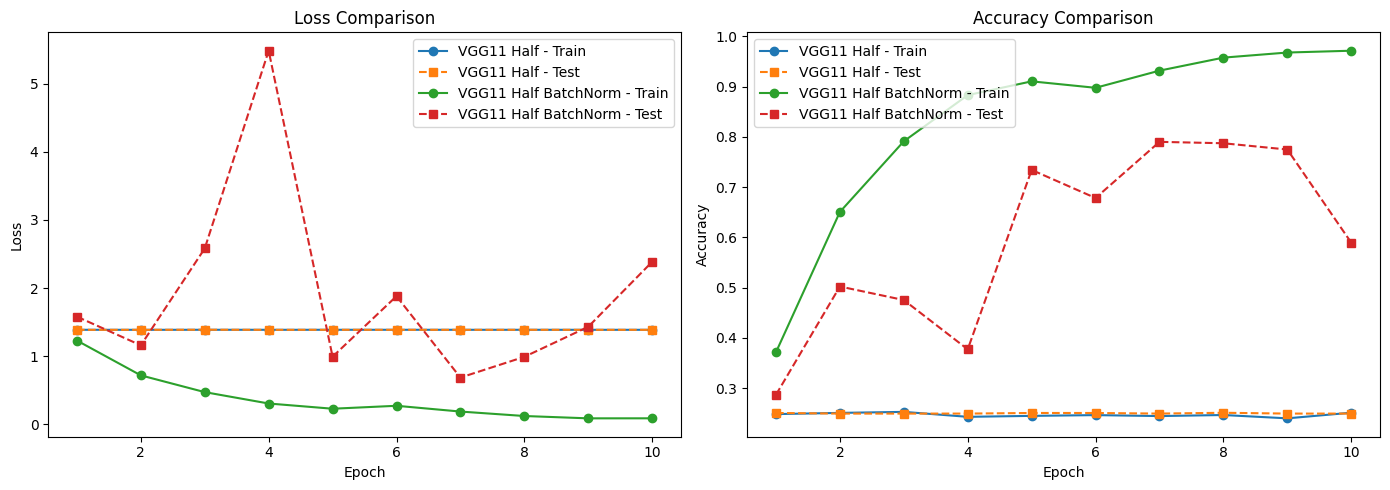

In [13]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

import matplotlib.pyplot as plt


def load_scalars(log_dir, tag):
    ea = EventAccumulator(str(log_dir))
    ea.Reload()
    if tag not in ea.Tags().get("scalars", []):
        return [], []
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    return steps, values


metrics = [
    ("Loss/train_epoch", "Train Loss"),
    ("Loss/test", "Test Loss"),
    ("Accuracy/train_epoch", "Train Accuracy"),
    ("Accuracy/test", "Test Accuracy"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for log_dir, label in [
    (TENSORBOARD_LOG_DIR, "VGG11 Half"),
    (TENSORBOARD_BN_LOG_DIR, "VGG11 Half BatchNorm"),
]:
    for tag, _ in metrics:
        steps, values = load_scalars(log_dir, tag)
        if not steps:
            continue
        ax = axes[0] if "Loss" in tag else axes[1]
        split = "Train" if "train" in tag.lower() else "Test"
        linestyle = "-" if split == "Train" else "--"
        marker = "o" if split == "Train" else "s"
        ax.plot(steps, values, linestyle=linestyle, marker=marker, label=f"{label} - {split}")

axes[0].set_title("Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].set_title("Accuracy Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()